<a href="https://colab.research.google.com/github/Amulyar04/python_amulya/blob/main/lab3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.tree import Tree
import re

# Download requried resources
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [34]:
# Download the CSV directly from GitHub
url='https://raw.githubusercontent.com/ramar92/NLP-Dataset/main/customer_reviews.csv'
df = pd.read_csv(url)
# Display a few rows
df.head()

,Review
0,I love this product! It's amazing and works pe...
1,This is the worst experience I've ever had.
2,"The product is okay, but I expected something ..."
3,Absolutely fantastic! Would buy again.
4,Not worth the price. Completely disappointed.


In [52]:
# Sentiment-related keywords for product reviews
sentiment_keywords = set([
    'love', 'amazing', 'perfectly', 'fantastic', 'happy', 'super', 'best', 'good', 'worth', 'decent',
    'worst', 'disappointed', 'terrible', 'bad', 'disappointing', 'poor', 'broke', 'not worth', 'okay'
])

def extract_sentiment_keywords(text):
  # Create a lowercase version of the sentiment_keywords set for comparison
  lowercase_sentiment_keywords = {keyword.lower() for keyword in sentiment_keywords}
  # Convert the input text to lowercase and tokenize it
  tokens = {word.lower() for word in word_tokenize(text)}
  # Find the intersection of the lowercase tokens and lowercase sentiment keywords
  found_lowercase_keywords = lowercase_sentiment_keywords.intersection(tokens)
  # Return the original casing of the keywords that were found
  return [keyword for keyword in sentiment_keywords if keyword.lower() in found_lowercase_keywords]

In [44]:
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.tree import Tree
import re
def extract_named_entities(text):
  entities = {'PERSON':[],'ORGANIZATION':[],'GPE':[]}
  chunked = ne_chunk(pos_tag(word_tokenize(text)))
  for subtree in chunked:
    if isinstance(subtree, Tree):
      label = subtree.label()
      entity = " ".join([token for token, pos in subtree.leaves()])
      if label in entities:
        entities[label].append(entity)
  return entities

In [54]:
import nltk
nltk.download('maxent_ne_chunker_tab')
nltk.download('punkt_tab') # Added to download the missing resource
nltk.download('averaged_perceptron_tagger_eng') # Added to download the missing resource
sample_text = df['Review'].iloc[0]
ner_result = extract_named_entities(sample_text)
keywords_result = extract_sentiment_keywords(sample_text) # Updated function call and variable name

print("\nNamed Entities:")
print(ner_result)
print("\nExtracted Keywords:") # Updated print statement
print(keywords_result)

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!



Named Entities:
{'PERSON': [], 'ORGANIZATION': [], 'GPE': []}

Extracted Keywords:
['perfectly', 'love', 'amazing']


In [53]:
results = []
for idx, row in df.head(10).iterrows():
  text = row['Review']
  # Use the new sentiment keyword extraction function
  keywords = extract_sentiment_keywords(text)
  ner = extract_named_entities(text)
  results.append({
      "ID": idx,
      "Keywords": keywords, # Changed 'Skills' to 'Keywords' for clarity
      "Entities": ner
  })

result_df = pd.DataFrame(results)
result_df.head()

,ID,Keywords,Entities
0,0,"[perfectly, love, amazing]","{'PERSON': [], 'ORGANIZATION': [], 'GPE': []}"
1,1,[worst],"{'PERSON': [], 'ORGANIZATION': [], 'GPE': []}"
2,2,[okay],"{'PERSON': [], 'ORGANIZATION': [], 'GPE': []}"
3,3,[fantastic],"{'PERSON': [], 'ORGANIZATION': [], 'GPE': []}"
4,4,"[worth, disappointed]","{'PERSON': [], 'ORGANIZATION': [], 'GPE': []}"


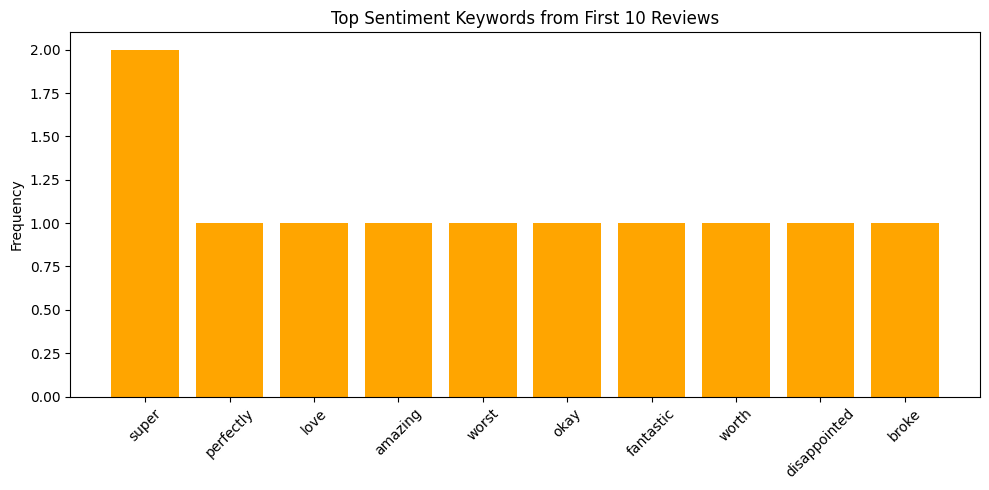

In [55]:
from collections import Counter
import matplotlib.pyplot as plt

all_skills = []
for item in result_df['Keywords']: # Changed 'Skills' to 'Keywords'
    all_skills.extend(item)

skill_freq = Counter(all_skills)
top_skills = skill_freq.most_common(10)

labels, values = zip(*top_skills)

plt.figure(figsize=(10,5))
plt.bar(labels, values, color='orange')
plt.title("Top Sentiment Keywords from First 10 Reviews") # Updated title
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()